## Clone repo

In [ ]:
!git clone -b haehyun --single-branch https://@github.com/chriss006/CaseStudy.git
%cd CaseStudy

Cloning into 'CaseStudy'...
remote: Enumerating objects: 1321, done.
remote: Counting objects: 100% (1067/1067), done.
remote: Compressing objects: 100% (53/53), done.
remote: Total 1321 (delta 1040), reused 1024 (delta 1014), pack-reused 254 (from 1)
Receiving objects: 100% (1321/1321), 627.72 MiB | 42.64 MiB/s, done.
Resolving deltas: 100% (1143/1143), done.
Updating files: 100% (1046/1046), done.
/kaggle/working/CaseStudy


In [2]:
!git pull

Already up to date.


In [3]:
# Upgrade pip first
!pip install --upgrade pip

# Install compatible versions of key packages
!pip install transformers==4.57.1
!pip install accelerate
!pip install peft
!pip install trl==0.8.6
!pip install datasets
!pip install bitsandbytes

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 24.2 MB/s eta 0:00:00
  Attempting uninstall: pip
    Found existing installation: pip 24.1.2
    Uninstalling pip-24.1.2:
      Successfully uninstalled pip-24.1.2
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 21.1 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 19.4 MB/s  0:00:00
  Attempting uninstall: huggingface-hub
    Found existing installation: huggingface_hub 1.4.1
    Uninstalling huggingface_hub-1.4.1:
      Successfully uninstalled huggingface_hub-1.4.1
  Attempting uninstall: transformers
    Found existing installation: transformers 5.2.0
    Uninstalling transformers-5.2.0:
      Successfully uninstalled transformers-5.2.0
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [transformers]
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [trl]
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 31.6 MB/s  0:00:01


In [4]:
import bitsandbytes as bnb
print("BitsAndBytes version:", bnb.__version__)

BitsAndBytes version: 0.49.2


## Fewshot inference

In [5]:
!cat src/openllama/fewshot_noc_text.py

import json
from typing import Any, Dict, List, Tuple, Optional

SPEC_KEY_ORDER = ["inits", "targets", "connectivity", "floorplan_dim", "blockages"]

def _stable_spec(spec: Dict[str, Any]) -> Dict[str, Any]:
    out: Dict[str, Any] = {}
    for k in SPEC_KEY_ORDER:
        if k in spec:
            out[k] = spec[k]
    for k in spec.keys():
        if k not in out:
            out[k] = spec[k]
    return out

def _dumps_compact(obj: Any) -> str:
    return json.dumps(obj, ensure_ascii=False, separators=(",", ":"))

def _compress_blockages_for_prompt(spec: Dict[str, Any]) -> Dict[str, Any]:
    """
    Keep blockages but compress to reduce tokens:
      blockages_compact: [[x,y,w,h], ...]
    Also keep original keys inits/targets/connectivity/floorplan_dim.
    """
    spec = dict(spec)
    blockages = spec.get("blockages", {}) or {}
    compact: List[List[int]] = []
    for _, b in blockages.items():
        # tolerate int/float inputs, cast to int for prompt clarity
        compact.ap

In [6]:
%%writefile src/validate_architecture.py
#!/usr/bin/env python3
"""NoC Architecture Validation Module"""
import json
from typing import Dict, Tuple

class ArchitectureValidator:
    def __init__(self, spec: Dict, output: Dict):
        self.spec = spec
        self.output = output
        self.errors = []
        self.warnings = []
    
    def validate_all(self) -> Tuple[bool, Dict]:
        self.errors = []
        self.warnings = []
        
        self._validate_switch_placement()
        self._validate_path_elements()
        self._validate_route_connectivity()
        self._validate_no_cycles()
        
        is_valid = len(self.errors) == 0
        
        report = {
            "valid": is_valid,
            "errors": self.errors,
            "warnings": self.warnings,
            "checks": {
                "switch_placement": not self._has_error("switch_placement"),
                "path_elements": not self._has_error("path_elements"),
                "route_connectivity": not self._has_error("route_connectivity"),
                "no_cycles": not self._has_error("cycles")
            }
        }
        
        return is_valid, report
    
    def _has_error(self, error_type: str) -> bool:
        return any(error_type in e for e in self.errors)
    
    def _validate_switch_placement(self):
        floorplan = self.spec.get("floorplan_dim", [1000, 1000])
        max_x, max_y = floorplan[0], floorplan[1]
        blockages = self.spec.get("blockages", {})
        switches = self.output.get("switches", {})
        
        for switch_id, coords in switches.items():
            x, y = coords["x"], coords["y"]
            
            if not (0 <= x <= max_x and 0 <= y <= max_y):
                self.errors.append(
                    f"switch_placement: {switch_id} at ({x}, {y}) outside bounds ({max_x}, {max_y})"
                )
            
            for block_id, block in blockages.items():
                bx, by = block["x"], block["y"]
                bw, bh = block["width"], block["height"]
                
                if (bx <= x <= bx + bw) and (by <= y <= by + bh):
                    self.errors.append(
                        f"switch_placement: {switch_id} at ({x}, {y}) inside blockage {block_id}"
                    )
    
    def _validate_path_elements(self):
        inits = set(self.spec.get("inits", {}).keys())
        targets = set(self.spec.get("targets", {}).keys())
        switches = set(self.output.get("switches", {}).keys())
        
        all_valid_nodes = inits | targets | switches
        routing_paths = self.output.get("routing_paths", {})
        
        for route_id, path in routing_paths.items():
            if not isinstance(path, list):
                self.errors.append(f"path_elements: {route_id} path is not a list")
                continue
            
            for node in path:
                if node not in all_valid_nodes:
                    self.errors.append(
                        f"path_elements: {route_id} contains non-existent node '{node}'"
                    )
    
    def _validate_route_connectivity(self):
        connectivity = self.spec.get("connectivity", {})
        routing_paths = self.output.get("routing_paths", {})
        
        for route_id, (init, target) in connectivity.items():
            if route_id not in routing_paths:
                self.errors.append(
                    f"route_connectivity: Required route {route_id} ({init}->{target}) is missing"
                )
                continue
            
            path = routing_paths[route_id]
            
            if len(path) < 2:
                self.errors.append(
                    f"route_connectivity: {route_id} path too short"
                )
            elif path[0] != init:
                self.errors.append(
                    f"route_connectivity: {route_id} should start with {init}, got {path[0]}"
                )
            elif path[-1] != target:
                self.errors.append(
                    f"route_connectivity: {route_id} should end with {target}, got {path[-1]}"
                )
    
    def _validate_no_cycles(self):
        routing_paths = self.output.get("routing_paths", {})
        
        for route_id, path in routing_paths.items():
            if not isinstance(path, list) or len(path) < 2:
                continue
            
            seen_nodes = set()
            for node in path:
                if node in seen_nodes:
                    self.errors.append(
                        f"cycles: Route {route_id} contains loop - '{node}' appears multiple times"
                    )
                    break
                seen_nodes.add(node)

def validate_architecture(spec: Dict, output: Dict) -> Tuple[bool, Dict]:
    validator = ArchitectureValidator(spec, output)
    return validator.validate_all()

Writing src/validate_architecture.py


In [7]:
# =========================
# FEWSHOT STAGE2: INFERENCE + (SAME) VALIDATION + SAVE JSONL
# =========================
import os
import json
import yaml
import torch
from typing import Any, Dict, Optional, List, Tuple

from tqdm.notebook import tqdm
from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
from transformers import StoppingCriteria, StoppingCriteriaList
from peft import PeftModel

from src.openllama.fewshot_noc_text import build_fewshot_stage2_text_prompt
from src.validate_architecture import validate_architecture  # ✅ same validator as finetuning


# Stopping criteria
class StopOnEnd(StoppingCriteria):
    """
    Stops when the generated tokens end with "\nEND" (preferred),
    or "END" if tokenizer doesn't encode "\nEND" cleanly.
    """
    def __init__(self, tokenizer):
        self.tok = tokenizer
        self.end_ids = tokenizer.encode("\nEND", add_special_tokens=False)
        if len(self.end_ids) == 0:
            self.end_ids = tokenizer.encode("END", add_special_tokens=False)

    def __call__(self, input_ids, scores, **kwargs):
        if input_ids.shape[1] < len(self.end_ids):
            return False
        tail = input_ids[0, -len(self.end_ids):].tolist()
        return tail == self.end_ids


# CONFIG
TEST_FP = "/kaggle/input/datasets/haehyunlee/noc-singleshot/test_splits/test_part_2.jsonl"
CFG_PATH = "/kaggle/working/CaseStudy/configs/llama7b.yaml"
OUT_DIR = "/kaggle/working/CaseStudy/outputs/fewshot_stage2_text/"
CKPT_DIR = "/kaggle/input/datasets/chetana092004/llama7b-stage1-ckpt/v2/checkpoint-3200"

BATCH_SIZE = 1
MAX_NEW_TOKENS = 1024
N_SHOTS = 1
START_IDX = 0  
N_SAMPLES = 50

PRED_PATH = os.path.join(OUT_DIR, f"predictions-{START_IDX+N_SAMPLES}.jsonl")
STATS_PATH = os.path.join(OUT_DIR, "stats.json")
os.makedirs(OUT_DIR, exist_ok=True)

def parse_stage2_text(pred_text: str) -> Tuple[Optional[Dict[str, Any]], Dict[str, Any]]:
    dbg = {"error": None, "lines": 0}

    txt = pred_text.strip().replace("\r\n", "\n").replace("\r", "\n")
    lines = [ln.strip() for ln in txt.split("\n") if ln.strip()]
    dbg["lines"] = len(lines)

    # Start from BEGIN_OUTPUT if present, else from SWITCHES
    if "BEGIN_OUTPUT" in lines:
        i_begin = lines.index("BEGIN_OUTPUT")
        lines = lines[i_begin:]
    elif "SWITCHES" in lines:
        i_sw0 = lines.index("SWITCHES")
        lines = lines[i_sw0:]
    else:
        dbg["error"] = "Missing SWITCHES (and BEGIN_OUTPUT)"
        return None, dbg

    # Locate sections
    try:
        i_sw = lines.index("SWITCHES")
        i_rt = lines.index("ROUTES")
        i_end = lines.index("END") if "END" in lines else len(lines)
    except ValueError:
        dbg["error"] = "Missing SWITCHES or ROUTES marker"
        return None, dbg

    if not (i_sw < i_rt <= i_end):
        dbg["error"] = "Section order invalid"
        return None, dbg

    sw_lines = lines[i_sw + 1 : i_rt]
    rt_lines = lines[i_rt + 1 : i_end]

    switches: Dict[str, Dict[str, int]] = {}
    routes: Dict[str, List[str]] = {}

    # Switch lines: "s_k x y"
    for ln in sw_lines:
        parts = ln.split()
        if len(parts) != 3:
            dbg["error"] = f"Bad switch line: {ln}"
            return None, dbg
        sid, xs, ys = parts
        if not sid.startswith("s_"):
            dbg["error"] = f"Bad switch id: {sid}"
            return None, dbg
        try:
            x = int(xs)
            y = int(ys)
        except Exception:
            dbg["error"] = f"Non-integer switch coords: {ln}"
            return None, dbg
        switches[sid] = {"x": x, "y": y}

    # Route lines: "r_k node0 node1 ... nodeN"
    for ln in rt_lines:
        parts = ln.split()
        if len(parts) < 3:
            dbg["error"] = f"Bad route line: {ln}"
            return None, dbg
        rid = parts[0]
        path = parts[1:]
        if not rid.startswith("r_"):
            dbg["error"] = f"Bad route id: {rid}"
            return None, dbg
        routes[rid] = path

    return {"switches": switches, "routing_paths": routes}, dbg


# -------------------------
# Helpers: dataset fields
# -------------------------
def get_spec(row: Dict[str, Any]) -> Dict[str, Any]:
    if "spec" in row and isinstance(row["spec"], dict):
        return row["spec"]
    if "Arch Specification" in row and isinstance(row["Arch Specification"], dict):
        return row["Arch Specification"]
    raise KeyError("Cannot find spec in row. Expected row['spec'].")

def get_gt_network(row: Dict[str, Any]) -> Tuple[Optional[Dict[str, Any]], Optional[Dict[str, Any]]]:
    gt_sw = row.get("switches")
    gt_rt = row.get("routing_paths")
    net = row.get("network")
    if isinstance(net, dict):
        gt_sw = gt_sw or net.get("switches")
        gt_rt = gt_rt or net.get("routing_paths")
    return gt_sw, gt_rt


# LOAD CONFIG / MODEL
with open(CFG_PATH) as f:
    cfg = yaml.safe_load(f)

tok = AutoTokenizer.from_pretrained(cfg["model_name"], use_fast=True)
if tok.pad_token is None:
    tok.pad_token = tok.eos_token
tok.padding_side = "left"
tok.truncation_side = "left"

quant_cfg = BitsAndBytesConfig(
    load_in_4bit=cfg["load_in_4bit"],
    bnb_4bit_quant_type=cfg["bnb_4bit_quant_type"],
    bnb_4bit_compute_dtype=getattr(torch, cfg["bnb_4bit_compute_dtype"]),
    bnb_4bit_use_double_quant=cfg["bnb_4bit_use_double_quant"],
)

base = AutoModelForCausalLM.from_pretrained(
    cfg["model_name"],
    quantization_config=quant_cfg,
    device_map="auto",
)
base.config.use_cache = True

model = PeftModel.from_pretrained(base, CKPT_DIR)
model.eval()


# LOAD DATA 
raw = load_dataset("text", data_files={"test": TEST_FP})["test"]
end_idx = min(START_IDX + N_SAMPLES, len(raw))
raw = raw.select(range(START_IDX, end_idx))
data = [json.loads(x["text"]) for x in raw]

total_batches = (len(data) + BATCH_SIZE - 1) // BATCH_SIZE

# STATS 
stats = {
    "n_total": 0,
    "parsed_ok": 0,
    "valid_arch": 0,
    "check_switch_placement": 0,
    "check_path_elements": 0,
    "check_route_connectivity": 0,
    "check_no_cycles": 0,
}

def rate(x: int, n: int) -> float:
    return round(x / n, 4) if n else 0.0


# RUN + SAVE JSONL
with open(PRED_PATH, "w", encoding="utf-8") as fout:
    for batch in tqdm(
        (data[i:i + BATCH_SIZE] for i in range(0, len(data), BATCH_SIZE)),
        total=total_batches,
        desc="Batches",
    ):
        specs = [get_spec(r) for r in batch]
        prompts = [build_fewshot_stage2_text_prompt(s, n_shots=N_SHOTS) for s in specs]

        inputs = tok(
            prompts,
            return_tensors="pt",
            padding=True,
            truncation=True,
            max_length=cfg["max_seq_length"],
        ).to(model.device)

        with torch.no_grad():
            stopping = StoppingCriteriaList([StopOnEnd(tok)])
            # ✅ do_sample=False: remove temperature/top_p to avoid version-dependent errors
            outputs = model.generate(
                **inputs,
                max_new_tokens=MAX_NEW_TOKENS,
                do_sample=False,
                pad_token_id=tok.eos_token_id,
                eos_token_id=tok.eos_token_id,
                stopping_criteria=stopping,
            )

        input_len = inputs["input_ids"].shape[1]
        gen_only = outputs[:, input_len:]
        pred_texts = tok.batch_decode(gen_only, skip_special_tokens=True)

        for row, spec, pred_text in zip(batch, specs, pred_texts):
            pred_text = pred_text.strip()
            parsed, dbg = parse_stage2_text(pred_text)
            gt_sw, gt_rt = get_gt_network(row)

            stats["n_total"] += 1
            ok_parsed = parsed is not None
            stats["parsed_ok"] += int(ok_parsed)

            if not ok_parsed:
                fout.write(json.dumps({
                    "pred_text": pred_text,
                    "parsed": None,
                    "parse_debug": dbg,
                    "spec": spec,
                    "gt_switches": gt_sw,
                    "gt_routing_paths": gt_rt,
                    "validation": None,
                    "is_valid": False,
                }, ensure_ascii=False) + "\n")
                continue

            # ✅ SAME validator as finetuning
            is_valid, vreport = validate_architecture(spec, parsed)
            checks = (vreport.get("checks") or {})

            stats["valid_arch"] += int(is_valid)
            stats["check_switch_placement"] += int(checks.get("switch_placement", False))
            stats["check_path_elements"] += int(checks.get("path_elements", False))
            stats["check_route_connectivity"] += int(checks.get("route_connectivity", False))
            stats["check_no_cycles"] += int(checks.get("no_cycles", False))

            fout.write(json.dumps({
                "pred_text": pred_text,
                "parsed": parsed,
                "parse_debug": dbg,
                "spec": spec,
                "gt_switches": gt_sw,
                "gt_routing_paths": gt_rt,
                "validation": vreport,
                "is_valid": is_valid,
            }, ensure_ascii=False) + "\n")


# SAVE STATS
n = stats["n_total"]
report = {
    "n_total": n,
    "parsed_ok_rate": rate(stats["parsed_ok"], n),

    # same checks as finetuning validator
    "valid_arch_rate": rate(stats["valid_arch"], n),
    "check_switch_placement_rate": rate(stats["check_switch_placement"], n),
    "check_path_elements_rate": rate(stats["check_path_elements"], n),
    "check_route_connectivity_rate": rate(stats["check_route_connectivity"], n),
    "check_no_cycles_rate": rate(stats["check_no_cycles"], n),

    "pred_file": PRED_PATH,
}

with open(STATS_PATH, "w") as f:
    json.dump(report, f, indent=2)

print("\n===== FEW-SHOT STAGE2 (SAME VALIDATION AS FINETUNING) =====")
print(json.dumps(report, indent=2))
print("\nSaved predictions to:", PRED_PATH)
print("Saved stats to:", STATS_PATH)

2026-03-03 22:33:24.235335: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1772577204.410599      24 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1772577204.458834      24 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1772577204.861454      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772577204.861491      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772577204.861494      24 computation_placer.cc:177] computation placer alr

tokenizer_config.json:   0%|          | 0.00/593 [00:00<?, ?B/s]

tokenizer.model:   0%|          | 0.00/512k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/330 [00:00<?, ?B/s]

You are using the default legacy behaviour of the <class 'transformers.models.llama.tokenization_llama.LlamaTokenizer'>. This is expected, and simply means that the `legacy` (previous) behavior will be used so nothing changes for you. If you want to use the new behaviour, set `legacy=False`. This should only be set if you understand what it means, and thoroughly read the reason why this was added as explained in https://github.com/huggingface/transformers/pull/24565 - if you loaded a llama tokenizer from a GGUF file you can ignore this message
You are using the default legacy behaviour of the <class 'transformers.models.llama.tokenization_llama_fast.LlamaTokenizerFast'>. This is expected, and simply means that the `legacy` (previous) behavior will be used so nothing changes for you. If you want to use the new behaviour, set `legacy=False`. This should only be set if you understand what it means, and thoroughly read the reason why this was added as explained in https://github.com/huggin

...

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/132 [00:00<?, ?B/s]

Generating test split: 0 examples [00:00, ? examples/s]

Batches:   0%|          | 0/50 [00:00<?, ?it/s]


===== FEW-SHOT STAGE2 (SAME VALIDATION AS FINETUNING) =====
{
  "n_total": 50,
  "parsed_ok_rate": 0.72,
  "valid_arch_rate": 0.0,
  "check_switch_placement_rate": 0.54,
  "check_path_elements_rate": 0.66,
  "check_route_connectivity_rate": 0.0,
  "check_no_cycles_rate": 0.72,
  "pred_file": "/kaggle/working/CaseStudy/outputs/fewshot_stage2_text/predictions-50.jsonl"
}

Saved predictions to: /kaggle/working/CaseStudy/outputs/fewshot_stage2_text/predictions-50.jsonl
Saved stats to: /kaggle/working/CaseStudy/outputs/fewshot_stage2_text/stats.json


## Save checkpoints

In [8]:
!zip -r llama7b_stage1_ckpt_2.zip /kaggle/working/CaseStudy/outputs/fewshot_stage2_validation/

	zip warning: name not matched: /kaggle/working/CaseStudy/outputs/fewshot_stage2_validation/

zip error: Nothing to do! (try: zip -r llama7b_stage1_ckpt_2.zip . -i /kaggle/working/CaseStudy/outputs/fewshot_stage2_validation/)


## Train loss curve

In [9]:
!ls /kaggle/input/datasets/chetana092004/llama7b-stage1-ckpt/v2/checkpoint-3200

adapter_config.json	   scaler.pt		    tokenizer.model
adapter_model.safetensors  scheduler.pt		    trainer_state.json
optimizer.pt		   special_tokens_map.json  training_args.bin
README.md		   tokenizer_config.json
rng_state.pth		   tokenizer.json


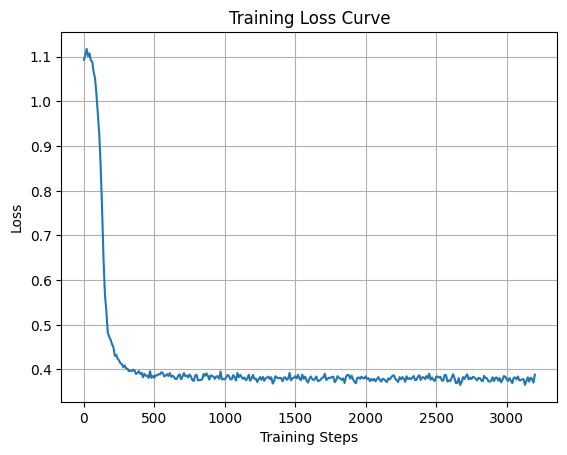

In [10]:
import json
import matplotlib.pyplot as plt

# Path to trainer_state.json
path = "/kaggle/input/datasets/chetana092004/llama7b-stage1-ckpt/v2/checkpoint-3200/trainer_state.json"

with open(path) as f:
    data = json.load(f)

log_history = data["log_history"]

steps = []
losses = []

for entry in log_history:
    if "loss" in entry:
        steps.append(entry["step"])
        losses.append(entry["loss"])

plt.figure()
plt.plot(steps, losses)
plt.xlabel("Training Steps")
plt.ylabel("Loss")
plt.title("Training Loss Curve")
plt.grid(True)
plt.show()